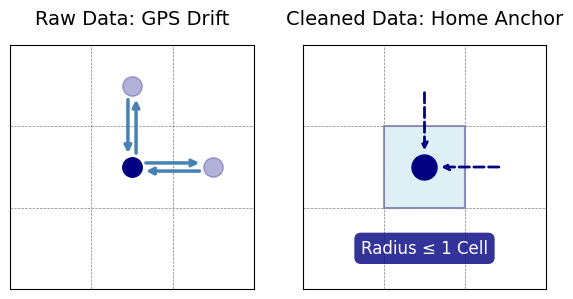

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_grid(ax, title):
    """Helper function to draw a 3x3 grid on a given matplotlib axis."""
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    
    # Draw grid lines
    for i in range(4):
        ax.axhline(i, color='gray', linestyle='--', linewidth=0.5)
        ax.axvline(i, color='gray', linestyle='--', linewidth=0.5)
        
    # Remove axis tick marks for a cleaner look
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_aspect('equal')

# 1. Set up the figure with two side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

# --- PLOT 1: RAW DATA (The Ping-Pong Effect) ---
draw_grid(ax1, "Raw Data: GPS Drift")

# Define the coordinates (center of the grid cells)
home_x, home_y = 1.5, 1.5       # The true home (Center)
drift1_x, drift1_y = 2.5, 1.5   # Drift to the right
drift2_x, drift2_y = 1.5, 2.5   # Drift above

# Plot the points (Using Navy Blue)
ax1.plot(home_x, home_y, marker='o', color='navy', markersize=14, label="Recorded Location")
ax1.plot(drift1_x, drift1_y, marker='o', color='navy', markersize=14, alpha=0.3)
ax1.plot(drift2_x, drift2_y, marker='o', color='navy', markersize=14, alpha=0.3)

# Draw arrows bouncing back and forth (Using safer 'arrowstyle' and Steel Blue)
# shrinkA and shrinkB prevent the arrows from overlapping the dots
props = dict(arrowstyle="->", color="steelblue", lw=2.5, shrinkA=10, shrinkB=10)

# Drift to the right and back
ax1.annotate("", xy=(drift1_x, drift1_y+0.05), xytext=(home_x, home_y+0.05), arrowprops=props)
ax1.annotate("", xy=(home_x, home_y-0.05), xytext=(drift1_x, drift1_y-0.05), arrowprops=props)

# Drift upwards and back
ax1.annotate("", xy=(drift2_x+0.05, drift2_y), xytext=(home_x+0.05, home_y), arrowprops=props)
ax1.annotate("", xy=(home_x-0.05, home_y), xytext=(drift2_x-0.05, drift2_y), arrowprops=props)

# --- PLOT 2: CLEANED DATA (The Home Anchor) ---
draw_grid(ax2, "Cleaned Data: Home Anchor")

# Highlight the anchor cell with a subtle light blue background
anchor_cell = patches.Rectangle((1, 1), 1, 1, linewidth=1.5, edgecolor='navy', facecolor='lightblue', alpha=0.4)
ax2.add_patch(anchor_cell)

# Plot the single anchored point
ax2.plot(home_x, home_y, marker='o', color='navy', markersize=18, label="Anchor Location")

# Draw dashed arrows pulling the drift back into the center
pull_props = dict(arrowstyle="->", color="navy", lw=2, ls="--", shrinkA=5, shrinkB=12)
ax2.annotate("", xy=(home_x, home_y), xytext=(drift1_x, drift1_y), arrowprops=pull_props)
ax2.annotate("", xy=(home_x, home_y), xytext=(drift2_x, drift2_y), arrowprops=pull_props)

# Add text to explain the radius
ax2.text(1.5, 0.5, "Radius ≤ 1 Cell", ha='center', va='center', fontsize=12, color='white', 
         bbox=dict(facecolor='navy', edgecolor='none', alpha=0.8, boxstyle="round,pad=0.4"))

# Adjust layout and show
plt.tight_layout()

plt.savefig("spatial drifting example.png", dpi=300, bbox_inches='tight')

plt.show()

In [1]:
import pandas as pd
df = pd.read_parquet("./data/enriched_human_mobility_100k.parquet")

🧠 1. Check POI topic distribution (LDA features)
❓ What this tells you
 - Are topics meaningful?
 - Are they skewed or balanced?
 - Do locations have distinct functional signatures?

📊 Plot: Topic distribution

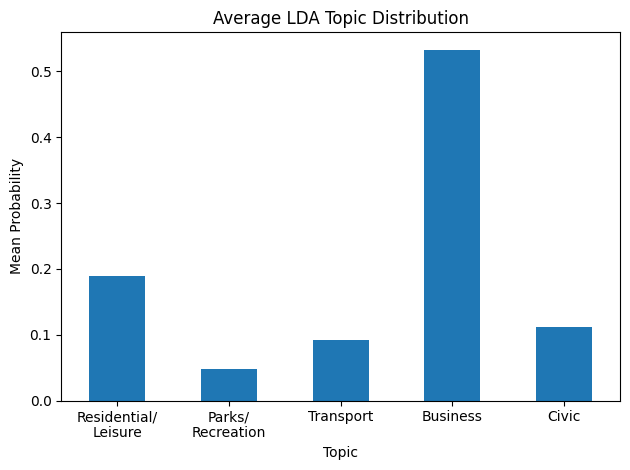

In [27]:
import matplotlib.pyplot as plt

# assume lda_cols = ['topic_0', ..., 'topic_6']
lda_cols = [col for col in df.columns if 'topic_' in col]

topic_means = df[lda_cols].mean()

topic_names = ['Residential/\nLeisure', 'Parks/\nRecreation', 'Transport', 'Business', 'Civic']
plt.figure()
topic_means.plot(kind='bar')
plt.title("Average LDA Topic Distribution")
plt.xlabel("Topic")
plt.ylabel("Mean Probability")
plt.xticks(rotation=0)
ax = plt.gca()

# Overwrite the labels
ax.set_xticks(range(len(topic_names)))
ax.set_xticklabels(topic_names, rotation=0, ha='center')

plt.tight_layout()
plt.savefig("lda_topic_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

📊 Plot: Topic distribution per location (spatial heatmap)

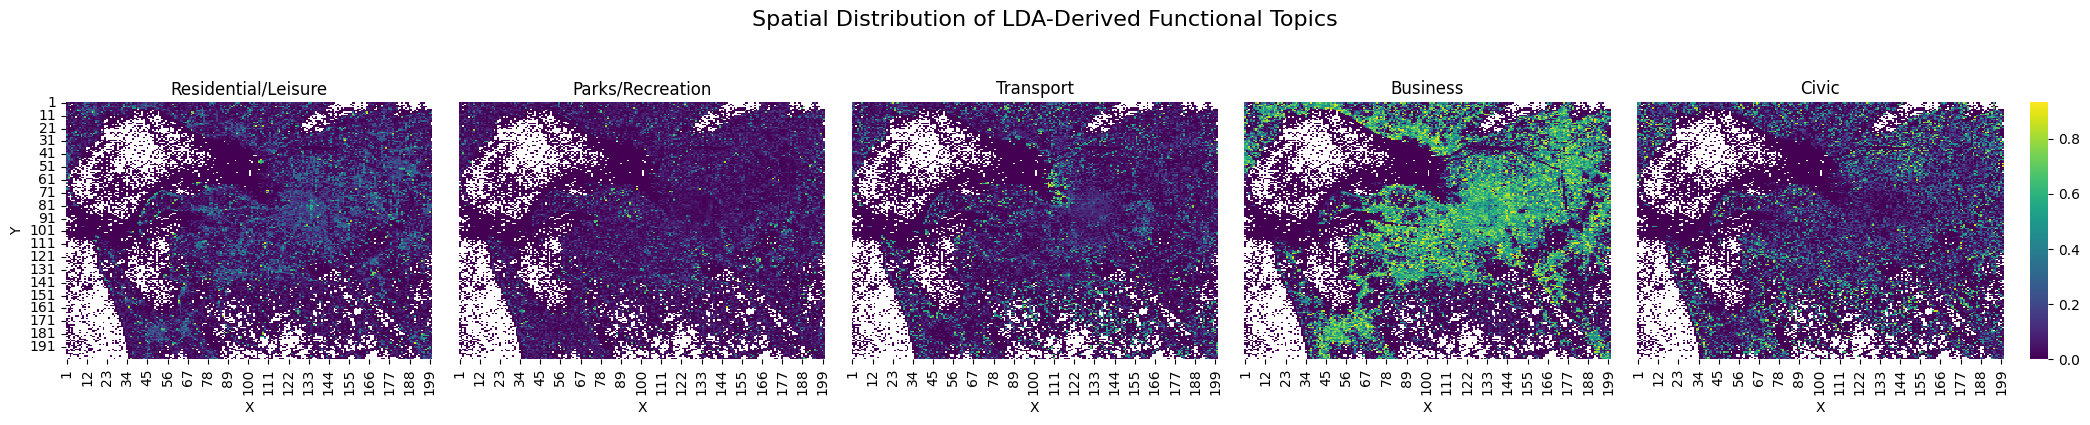

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

topic_names = ['Residential/Leisure', 'Parks/Recreation', 'Transport', 'Business', 'Civic']

# FIX 1: Create 1x6 subplots. The first 5 are equal width (1), the 6th is very thin (0.05) for the colorbar.
fig, axs = plt.subplots(1, 6, figsize=(21, 4), gridspec_kw={'width_ratios': [1, 1, 1, 1, 1, 0.05]})

for i, topic_name in enumerate(topic_names):
    topic_col = f'lda_topic_{i}'  
    pivot = df.pivot_table(index='y', columns='x', values=topic_col, aggfunc='mean')
    
    # FIX 2: Tell seaborn to put the colorbar in that tiny 6th axis (axs[5])
    sns.heatmap(pivot, ax=axs[i], cmap='viridis', 
                cbar=(i==4), 
                cbar_ax=axs[5] if i==4 else None)  
    
    axs[i].set_title(topic_name)
    axs[i].set_xlabel('X')
    
    # Clean up the Y-axis labels
    if i == 0:
        axs[i].set_ylabel('Y')
    else:
        axs[i].set_ylabel('')
        axs[i].set_yticks([]) # Hide ticks on the others so it looks continuous

plt.suptitle('Spatial Distribution of LDA-Derived Functional Topics', y=1.05, fontsize=16)

# plt.tight_layout() can sometimes fight with gridspec, so if it overlaps, comment this line out
plt.tight_layout()

plt.savefig("Spatial Distribution of LDA Topics 1.png", dpi=300, bbox_inches='tight')

plt.show()

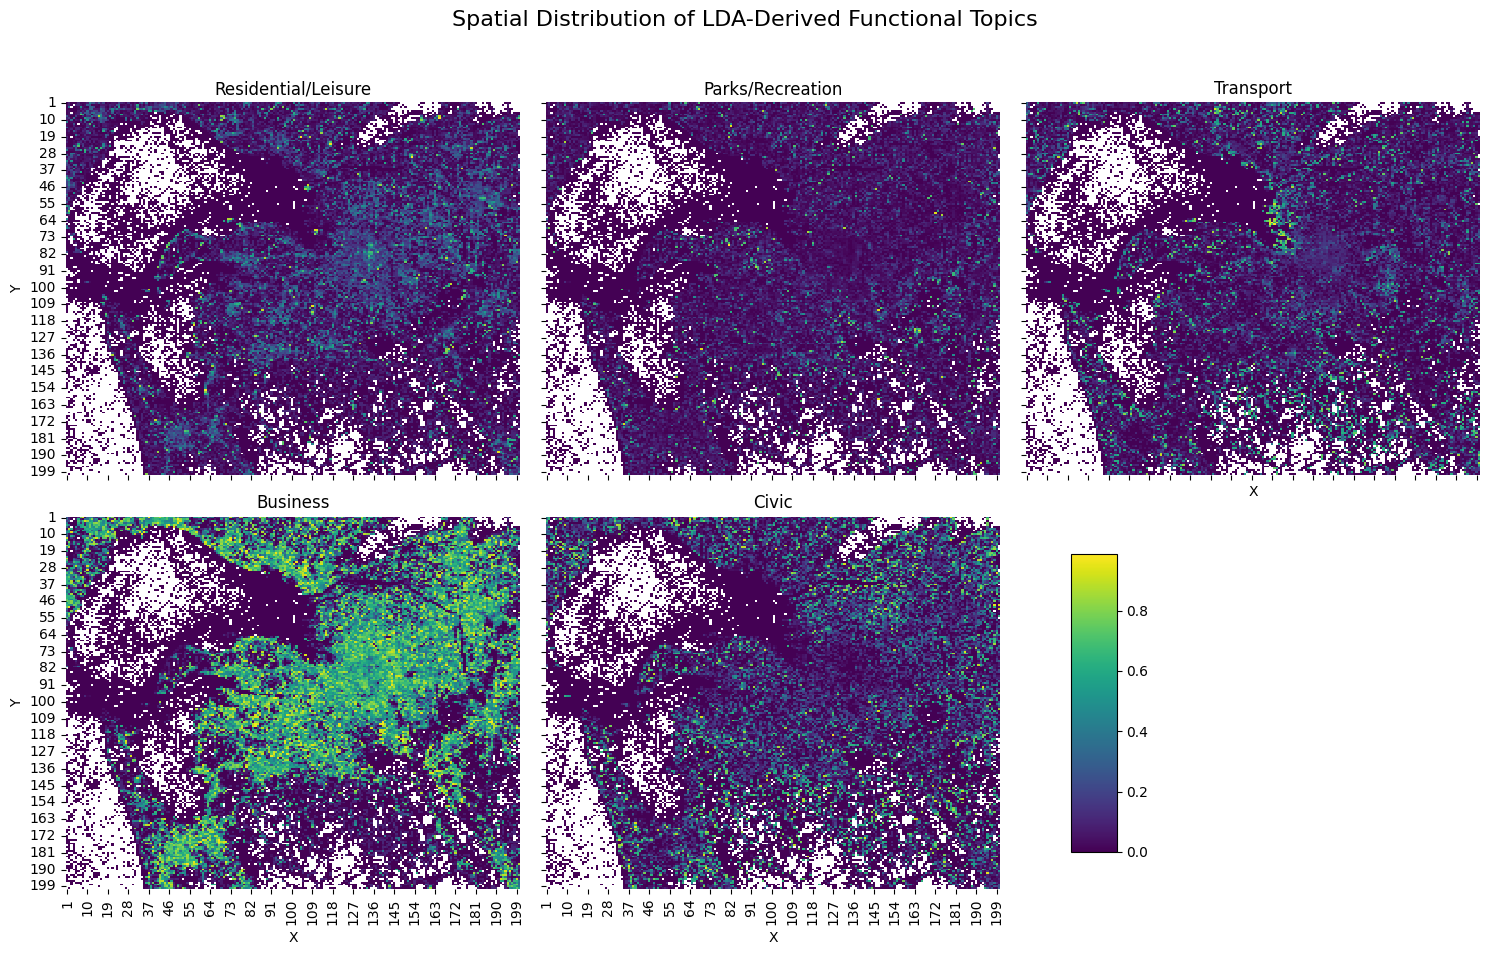

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

topic_names = ['Residential/Leisure', 'Parks/Recreation', 'Transport', 'Business', 'Civic']

# 1. Create a 2x3 grid (2 rows, 3 columns)
fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)

# 2. Flatten the 2D axes array into a 1D list so we can loop through it easily (0 to 5)
axs_flat = axs.flatten()

for i, topic_name in enumerate(topic_names):
    topic_col = f'lda_topic_{i}'  
    pivot = df.pivot_table(index='y', columns='x', values=topic_col, aggfunc='mean')
    
    # 3. Draw heatmaps WITHOUT colorbars to keep all sizes perfectly equal
    sns.heatmap(pivot, ax=axs_flat[i], cmap='viridis', cbar=False)  
    axs_flat[i].set_title(topic_name)
    
    # Clean up X-labels: Only show them on the "bottom" plots of each column (indices 2, 3, 4)
    if i in [2, 3, 4]:
        axs_flat[i].set_xlabel('X')
    else:
        axs_flat[i].set_xlabel('')
        
    # Clean up Y-labels: Only show them on the far-left plots (indices 0 and 3)
    if i % 3 == 0:
        axs_flat[i].set_ylabel('Y')
    else:
        axs_flat[i].set_ylabel('')

# 4. Handle the 6th slot (axs_flat[5]) which is empty
axs_flat[5].axis('off') # Hide the empty graph's borders and ticks

# 5. Place the colorbar inside the empty 6th slot's real estate
# inset_axes takes: [left_position, bottom_position, width, height] relative to the slot
cbar_ax = axs_flat[5].inset_axes([0.1, 0.1, 0.1, 0.8]) 
fig.colorbar(axs_flat[0].collections[0], cax=cbar_ax)

plt.suptitle('Spatial Distribution of LDA-Derived Functional Topics', y=0.95, fontsize=16)

# The rect argument takes a list: [left, bottom, right, top]
# Setting top to 0.93 forces all subplots to stay below the top 7% of the figure
plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig("Spatial Distribution of LDA Topics 2.png", dpi=300, bbox_inches='tight')

plt.show()

🧠 2. POI density distribution
❓ What this tells you
Is it skewed? (very likely)
Do you need log scaling?

📊 Plot: Histogram

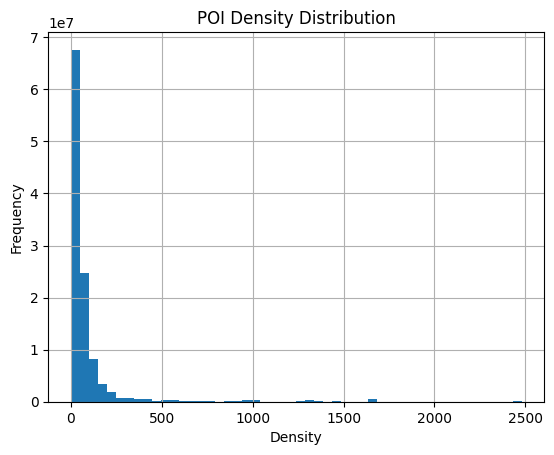

In [10]:
plt.figure()
df['poi_density'].hist(bins=50)
plt.title("POI Density Distribution")
plt.xlabel("Density")
plt.ylabel("Frequency")
plt.show()

📊 Better: Log-scale version

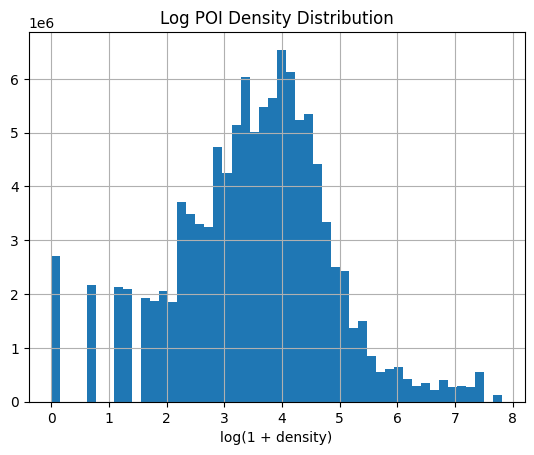

In [12]:
import numpy as np

plt.figure()
np.log1p(df['poi_density']).hist(bins=50)
plt.title("Log POI Density Distribution")
plt.xlabel("log(1 + density)")
plt.show()

🧠 3. Weekend vs weekday behavior
❓ What this tells you
Does movement differ on weekends?

📊 Plot: Density / activity comparison

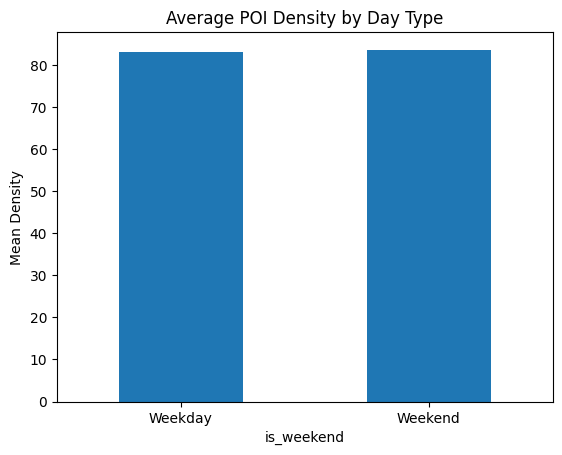

In [13]:
df['is_weekend'] = df['d'].isin([5,6]).astype(int)  # adjust if needed

weekend_density = df.groupby('is_weekend')['poi_density'].mean()

plt.figure()
weekend_density.plot(kind='bar')
plt.xticks([0,1], ['Weekday', 'Weekend'], rotation=0)
plt.title("Average POI Density by Day Type")
plt.ylabel("Mean Density")
plt.show()

📊 Plot: Temporal activity

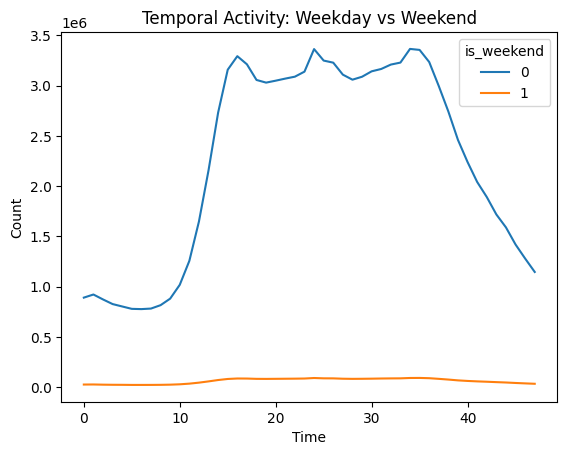

In [14]:
hourly = df.groupby(['t', 'is_weekend']).size().unstack()

hourly.plot()
plt.title("Temporal Activity: Weekday vs Weekend")
plt.xlabel("Time")
plt.ylabel("Count")
plt.show()

🧠 4. Person type behavior differences
❓ What this tells you
Do different users behave differently?

📊 Plot: POI density by person type

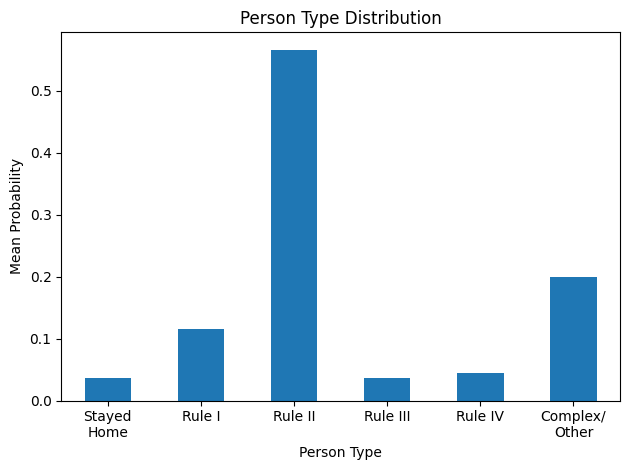

In [34]:
motif_cols = [col for col in df.columns if 'motif_' in col]

motif_means = df[motif_cols[:6]].mean()

motif_names = ['Stayed\nHome', 'Rule I', 'Rule II', 'Rule III', 'Rule IV', 'Complex/\nOther']

plt.figure()
motif_means.plot(kind='bar')
plt.title("Person Type Distribution")
plt.xlabel("Person Type")
plt.ylabel("Mean Probability")
plt.xticks(rotation=0)
ax = plt.gca()

# Overwrite the labels
ax.set_xticks(range(len(motif_names)))
ax.set_xticklabels(motif_names, rotation=0, ha='center')

plt.tight_layout()
plt.savefig("person_type_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

🧠 5. Spatial trajectory density

📊 Plot: Movement heatmap

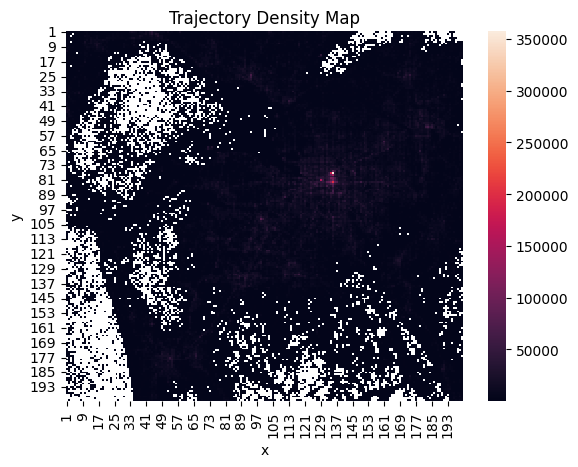

In [37]:
pivot = df.pivot_table(index='y', columns='x', values='uid', aggfunc='count')

plt.figure()
sns.heatmap(pivot)
plt.title("Trajectory Density Map")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

🧠 6. Correlation between features (IMPORTANT)
❓ What this tells you
Are features redundant?

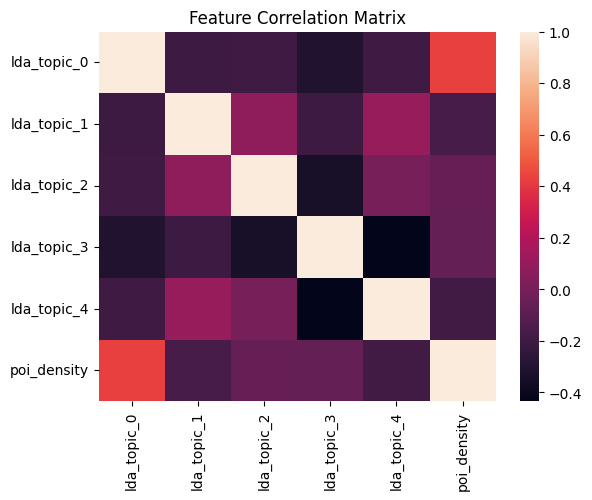

In [38]:
features = lda_cols + ['poi_density']

corr = df[features].corr()

plt.figure()
sns.heatmap(corr, annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

Plot: Home indicator

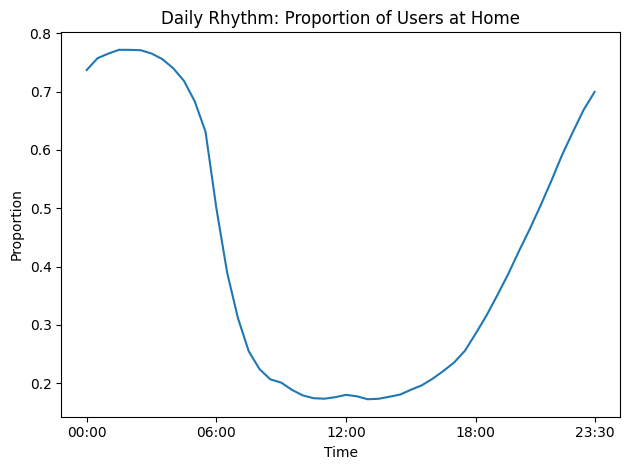

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

home_trend = df.groupby('t')['state'].mean()

home_trend.plot()
plt.title("Daily Rhythm: Proportion of Users at Home")
plt.xlabel("Time")
plt.ylabel("Proportion")

# t=0 is 00:00. Every 12 units = 6 hours.
tick_positions = [0, 12, 24, 36, 47]
tick_labels = ['00:00', '06:00', '12:00', '18:00', '23:30']

plt.xticks(ticks=tick_positions, labels=tick_labels)

plt.tight_layout()
plt.savefig("home_temporal_rhythm.png", dpi=300, bbox_inches='tight')
plt.show()

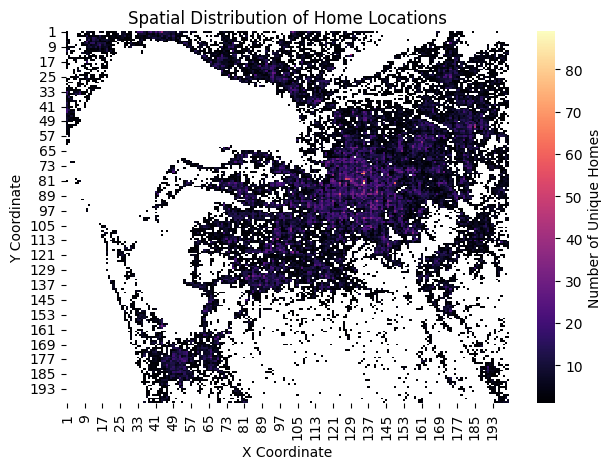

In [13]:
# Filter the dataset to ONLY include records where the user is at home
homes_only = df[df['state'] == 1]

# Count the number of unique users (or just total pings) in each X, Y grid cell
# We use nunique() on user_id to ensure a user who stays home all day isn't overcounted
home_density = homes_only.pivot_table(index='y', columns='x', values='uid', aggfunc='nunique')

# Draw the heatmap
sns.heatmap(home_density, cmap='magma', cbar_kws={'label': 'Number of Unique Homes'})

plt.title("Spatial Distribution of Home Locations")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.tight_layout()
plt.savefig("home_spatial_density.png", dpi=300, bbox_inches='tight')
plt.show()

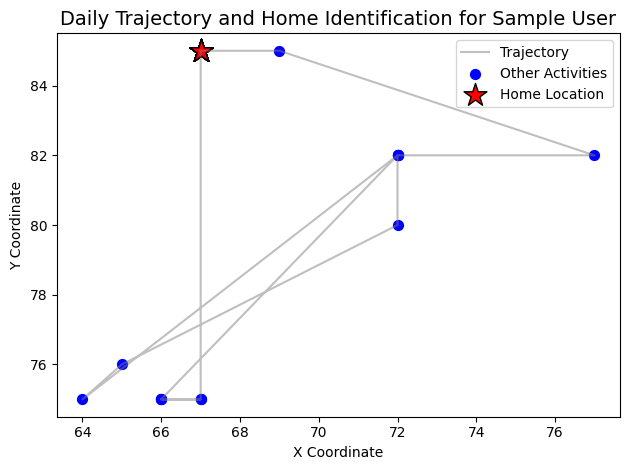

In [34]:
# Pick one active user ID to showcase
sample_user = df[(df['uid'] == 1) & (df['d'] == 1)]

# Separate home points from non-home points for this user
home_pts = sample_user[sample_user['state'] == 1]
away_pts = sample_user[sample_user['state'] == 0]

# Plot the trajectory line
plt.plot(sample_user['x'], sample_user['y'], color='gray', linestyle='-', alpha=0.5, label='Trajectory')

# Plot the away locations as small dots
plt.scatter(away_pts['x'], away_pts['y'], color='blue', s=50, label='Other Activities')

# Plot the home location as a large, distinct star
plt.scatter(home_pts['x'], home_pts['y'], color='red', marker='*', s=300, edgecolor='black', label='Home Location')

plt.title("Daily Trajectory and Home Identification for Sample User", fontsize=14)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()

plt.tight_layout()
plt.savefig("single_user_home_trajectory.png", dpi=300, bbox_inches='tight')
plt.show()